In [16]:
import sys
sys.path.insert(0, '/home/pranavsatheesh/packages/Packages/illustris_python')
sys.path.insert(0, '/home/pranavsatheesh/packages/Packages')
sys.path.insert(0, '/home/pranavsatheesh/packages')
sys.path.insert(0, '/home/pranavsatheesh/packages/ptorrey_packages')
sys.path.insert(0, '/home/pranavsatheesh/packages/arepo_python_tools')

import numpy as np
import illustris_python as il
import matplotlib.pyplot as plt
import scipy
import twoDplot as twod

print('illustris_python from:', il.__file__)
print('snapshot module:', il.snapshot.__file__)
print('has loadHeader:', hasattr(il.snapshot, 'loadHeader'))

illustris_python from: /home/pranavsatheesh/packages/Packages/illustris_python/__init__.py
snapshot module: /home/pranavsatheesh/packages/Packages/illustris_python/snapshot.py
has loadHeader: True


In [17]:
sys.path.append('../BH_dynamics_analysis')
sys.path.append('/home/pranavsatheesh/arepo_package/')
import BRAHMA_python as il_brahma
import arepo_package as arepo

In [18]:
basePathTNG = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'

In [19]:
basePath = '/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/SM5_TNG'
snapnum = 32

In [20]:
subhalo_data= il_brahma.groupcat.loadSubhalos_postprocessed(basePath,snapnum,fields=['SubhaloLenType','SubhaloHalfmassRad'])

In [21]:
il.snapshot.loadSubset(basePath,snapnum,5,fields=['Coordinates','ParticleIDs','BH_Hsml'])

{'count': 2533,
 'Coordinates': array([[ 1009.27124897,  3441.45606609,  3067.90866334],
        [ 1021.41482156,  3469.80401885,  3095.14211182],
        [ 1026.40519063,  3406.63517593,  2936.25210549],
        ...,
        [ 6961.78860895, 10843.49016127,  9209.39309782],
        [ 6626.87679497, 10175.18758587,  6563.66287362],
        [ 6681.87866457,  9853.56092774,  6163.62432701]]),
 'ParticleIDs': array([100285770535, 100033343719, 100036005898, ..., 100090655655,
        100066530649, 100044509433], dtype=uint64),
 'BH_Hsml': array([ 2.408979 ,  5.517282 ,  6.9371624, ..., 12.364757 , 20.244144 ,
         9.523292 ], dtype=float32)}

In [22]:
subhalo_pos = il.groupcat.loadSubhalos(basePath, snapnum, fields=['SubhaloPos'])

In [23]:
subhalo_pos[0]

array([1009.27423, 3441.467  , 3067.9211 ], dtype=float32)

In [24]:
from scipy.spatial.distance import cdist


In [25]:
bh_data = il.snapshot.loadSubset(basePath, snapnum, 5, fields=['Coordinates', 'ParticleIDs', 'BH_Hsml'])

# Get black hole coordinates
bh_coords = bh_data['Coordinates']

# Get subhalo position
subhalo_center = subhalo_pos[0]

# Calculate distances from subhalo center to all black holes
distances = cdist([subhalo_center], bh_coords)[0]

# Find the closest black hole
closest_bh_idx = np.argmin(distances)
closest_bh_distance = distances[closest_bh_idx]
closest_bh_coords = bh_coords[closest_bh_idx]

print(f"Closest black hole index: {closest_bh_idx}")
print(f"Distance to closest BH: {closest_bh_distance:.4f} ckpc/h")
print(f"Closest BH coordinates: {closest_bh_coords}")
print(f"Subhalo center: {subhalo_center}")
print(f"BH Hsml of closest BH: {bh_data['BH_Hsml'][closest_bh_idx]:.4f} ckpc/h")

Closest black hole index: 0
Distance to closest BH: 0.0169 ckpc/h
Closest BH coordinates: [1009.27124897 3441.45606609 3067.90866334]
Subhalo center: [1009.27423 3441.467   3067.9211 ]
BH Hsml of closest BH: 2.4090 ckpc/h


In [ ]:
bh_hsml_radius = bh_data['BH_Hsml'][closest_bh_idx] #ckpc/h

In [ ]:
snapnum=32,
subhalo_id = 0
subhalo_halfmass_rad = il.groupcat.loadSubhalos(basePath, snapnum, fields=['SubhaloHalfmassRad'])
halfmass_rad = float(subhalo_halfmass_rad[subhalo_id]) #ckpc/h

In [30]:
centre = subhalo_pos[0]

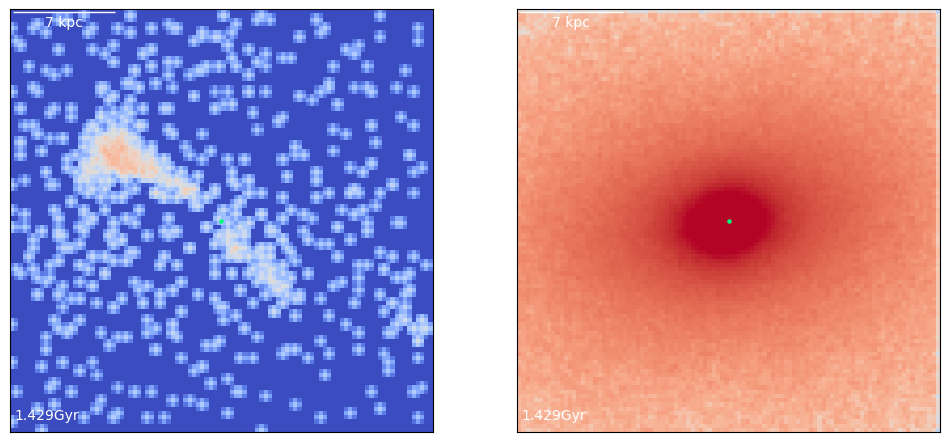

In [31]:
fig,axes = plt.subplots(1,2,figsize=(12,6))

gas_density_im = twod.galaxy2Dplots(
    path=basePath,
    snapnum=snapnum,
    p_type='0',
    particle_property='Density',
    view='xy',
    box_height=5,
    box_length=20,
    box_width=20,
    Nbins=100,
    method='binning',
    align=True,
    figure=fig,
    vmin=-4,
    vmax=3,
    centre=centre,
    axis=axes[0]
 )

stellar_density_im = twod.galaxy2Dplots(
    path=basePath,
    snapnum=snapnum,
    p_type='4',
    particle_property='Density',
    view='xy',
    box_height=5,
    box_length=20,
    box_width=20,
    Nbins=100,
    method='binning',
    align=True,
    figure=fig,
    vmin=-4,
    vmax=3,
    centre=centre,
    axis=axes[1]
 )

# SFR_im = twod.galaxy2Dplots(
#     path=basePath,
#     snapnum=snapnum,
#     p_type='4',
#     particle_property='StarFormationRate',
#     view='xy',
#     box_height=5,
#     box_length=20,
#     box_width=20,
#     Nbins=100,
#     method='binning',
#     align=True,
#     figure=fig,
#     axis=axes[2]
#  )

In [15]:
halfmass_rad

199.754638671875

In [17]:
header = il.snapshot.loadHeader(basePath, snapnum)
boxsize = header['BoxSize']
load_fields = ['Masses', 'Coordinates']


In [18]:
boxsize

12500.0

/home/pranavsatheesh/packages/arepo_python_tools/twoDplot.py:79: RuntimeWarning: invalid value encountered in divide
  zaxis = totL/np.linalg.norm(totL)


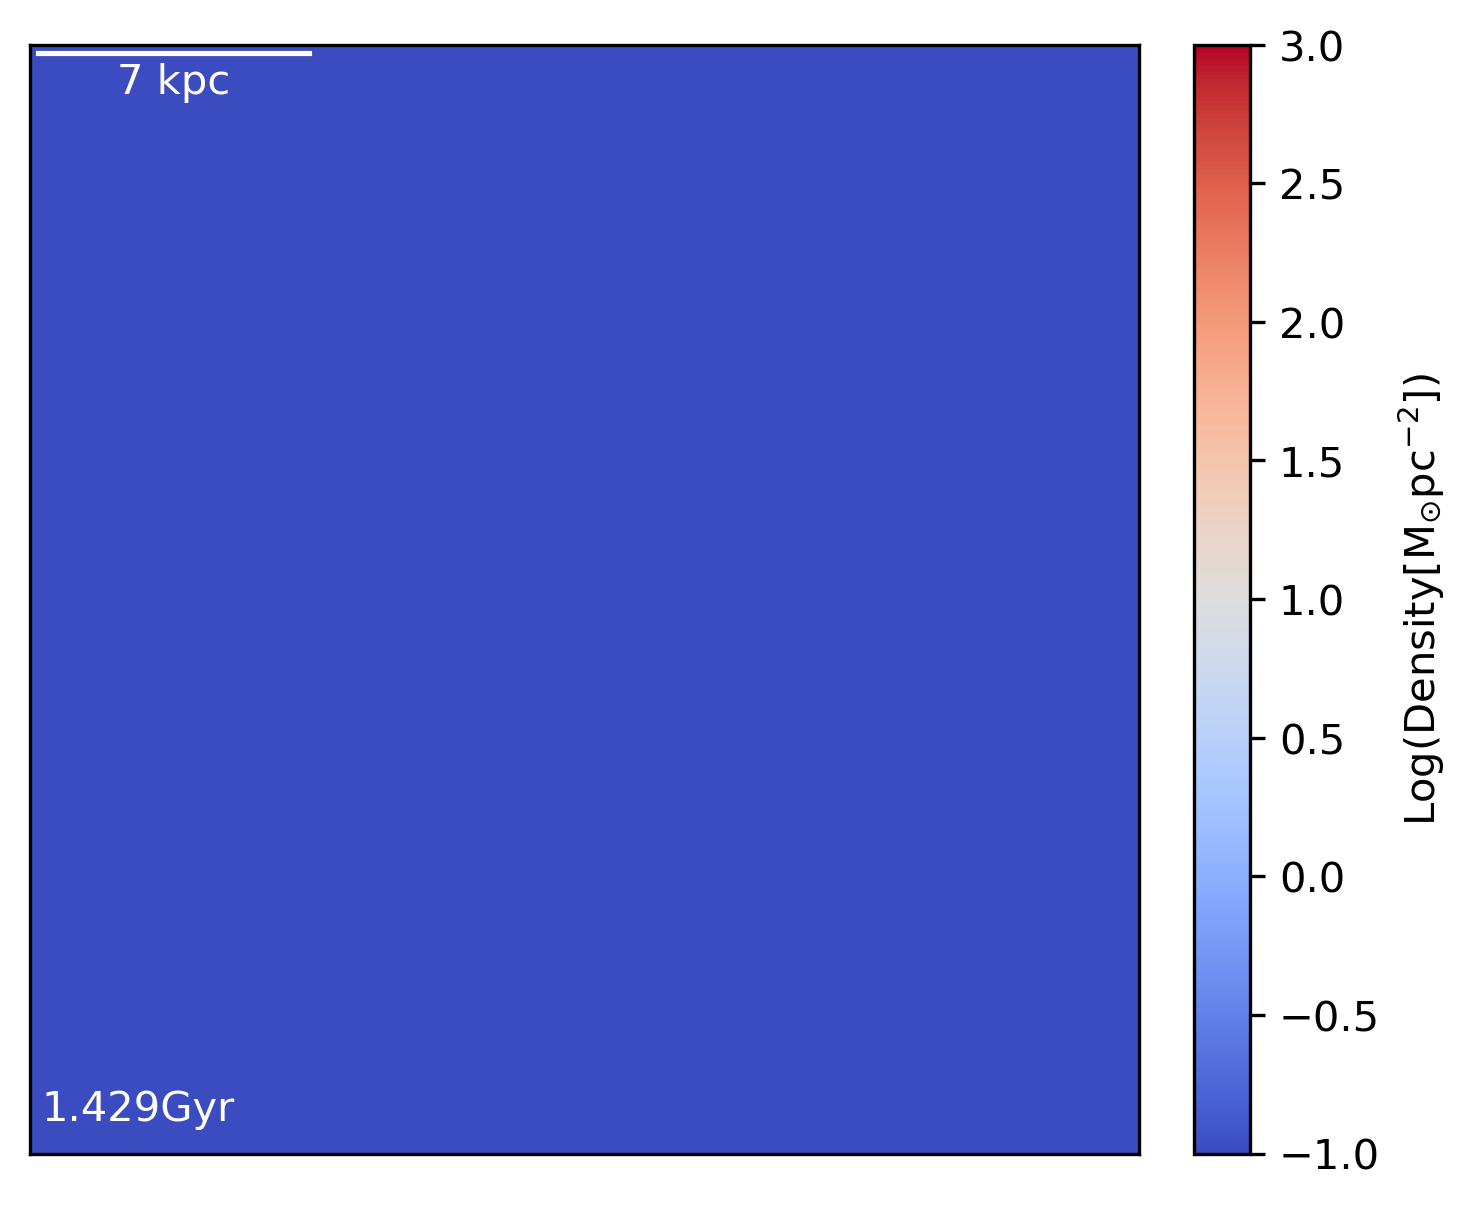

In [20]:
snapnum = 32

im = twod.galaxy2Dplots(
    path=basePath,
    snapnum=snapnum,
    p_type='0',
    particle_property='Density',
    view='xy',
    box_height=5,
    box_length=20,
    box_width=20,
    Nbins=1000,
    method='binning',
    align=True
 )
plt.show()